In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [3]:
X.shape

(1000, 2)

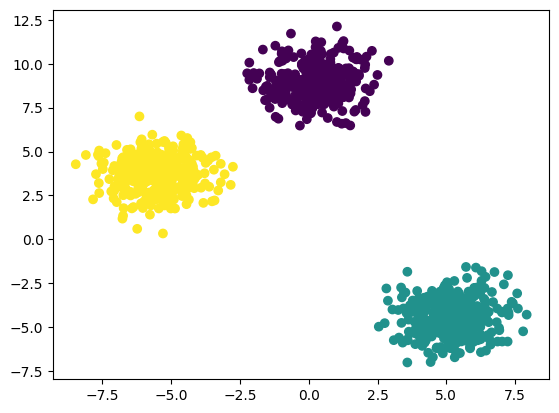

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.33,random_state=42)

In [8]:
from sklearn.cluster import KMeans

In [9]:
# Manual process
# Elbow method to calculate k value

In [11]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [12]:
wcss

[34827.57682552021,
 7935.437286145416,
 1319.2730531585607,
 1140.4677884655125,
 1015.2009190689728,
 853.8026393220299,
 813.9657870931487,
 686.3761598571044,
 581.1529831803829,
 531.2398521051465]

In [ ]:
#plot elbow curve

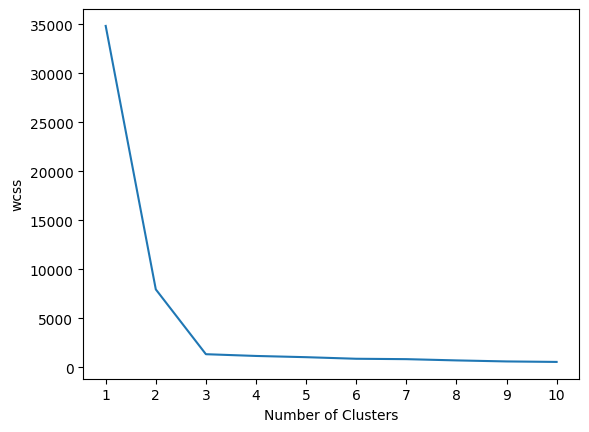

In [13]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("wcss")
plt.show()

In [14]:
kmeans = KMeans(n_clusters=k,init='k-means++')

In [16]:
y_labels = kmeans.fit_predict(X_train)

In [18]:
y_test_labels = kmeans.predict(X_test)

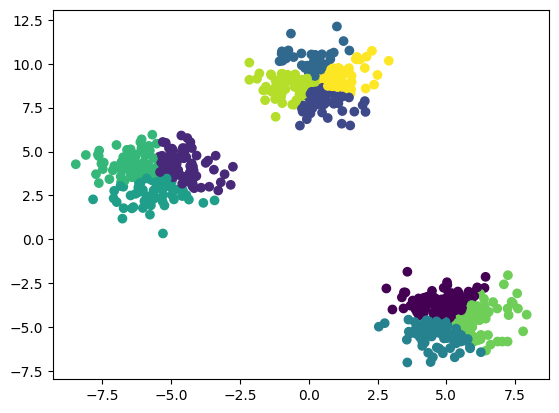

In [19]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

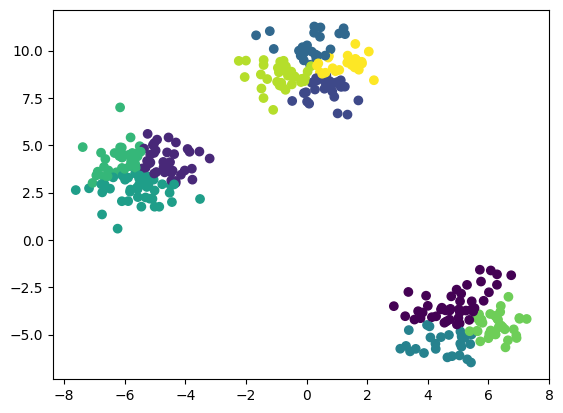

In [20]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_labels)

In [21]:
# knee locator
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from kneed import KneeLocator

In [27]:
kl = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
kl.elbow

np.int64(3)

In [ ]:
# performance metrics

In [30]:
from sklearn.metrics import silhouette_score

In [31]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train)
    score = silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

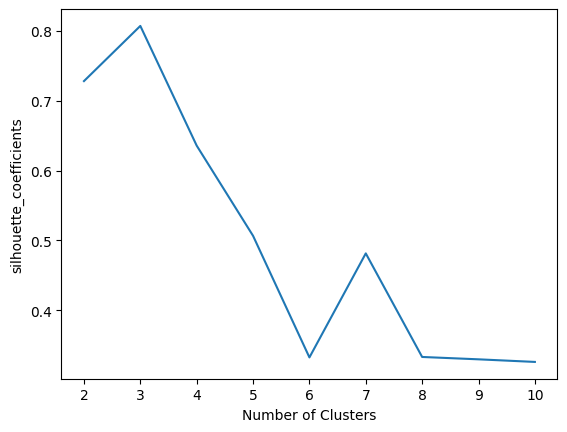

In [32]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("silhouette_coefficients")
plt.show()